<a href="https://colab.research.google.com/github/Devaki465/MachineLearning/blob/main/Salariesdataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
# Load dataset
df = pd.read_csv("salaries PDF.csv")

# Preview data
print(df.head())
print(df.info())


  company                  job     degree  salary_more_than_100k
0  google      sales executive  bachelors                      0
1  google      sales executive    masters                      0
2  google     business manager  bachelors                      1
3  google     business manager    masters                      1
4  google  computer programmer  bachelors                      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   company                16 non-null     object
 1   job                    16 non-null     object
 2   degree                 16 non-null     object
 3   salary_more_than_100k  16 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 644.0+ bytes
None


In [ ]:
print(df.describe(include='all'))


       company               job     degree  salary_more_than_100k
count       16                16         16                 16.000
unique       3                 3          2                    NaN
top     google  business manager  bachelors                    NaN
freq         6                 6          8                    NaN
mean       NaN               NaN        NaN                  0.625
std        NaN               NaN        NaN                  0.500
min        NaN               NaN        NaN                  0.000
25%        NaN               NaN        NaN                  0.000
50%        NaN               NaN        NaN                  1.000
75%        NaN               NaN        NaN                  1.000
max        NaN               NaN        NaN                  1.000


In [ ]:
print(df.isnull().sum())


company                  0
job                      0
degree                   0
salary_more_than_100k    0
dtype: int64


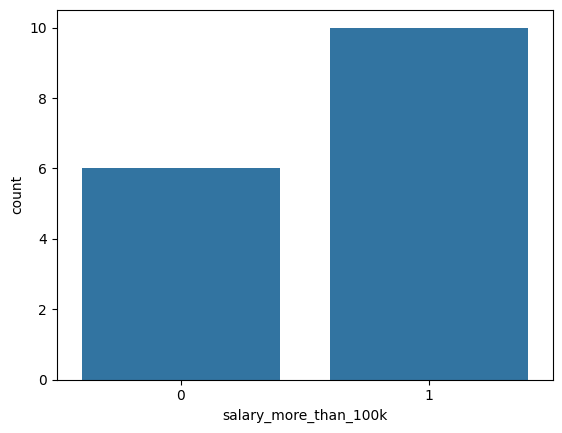

In [ ]:
sns.countplot(x='salary_more_than_100k', data=df)
plt.show()


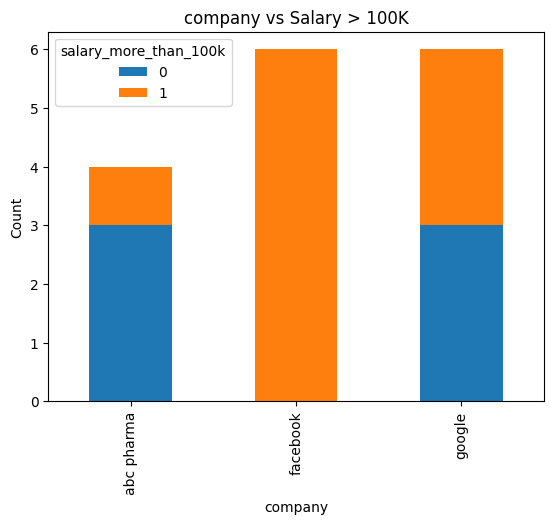

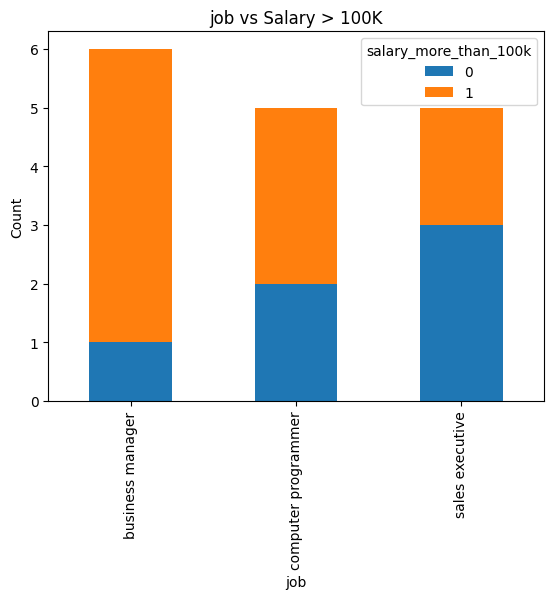

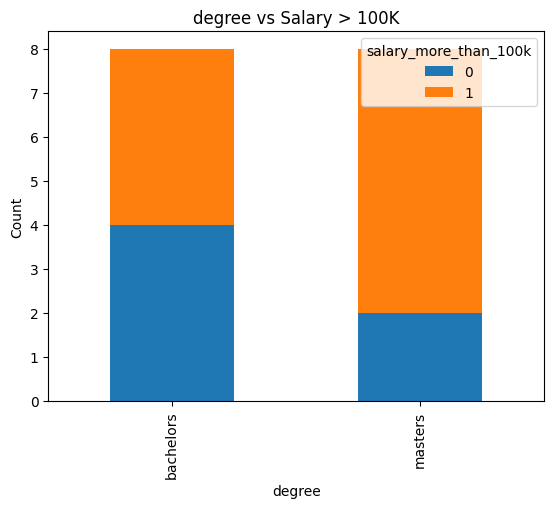

In [ ]:
for col in ['company', 'job', 'degree']:
    pd.crosstab(df[col], df['salary_more_than_100k']).plot(kind='bar', stacked=True)
    plt.title(f"{col} vs Salary > 100K")
    plt.ylabel("Count")
    plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

print(df.head())


   company  job  degree  salary_more_than_100k
0        2    2       0                      0
1        2    2       1                      0
2        2    0       0                      1
3        2    0       1                      1
4        2    1       0                      0


In [ ]:
X = df.drop('salary_more_than_100k', axis=1)
y = df['salary_more_than_100k']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

cart_model.fit(X_train, y_train)

y_pred_cart = cart_model.predict(X_test)

print("CART Accuracy:", accuracy_score(y_test, y_pred_cart))
print(classification_report(y_test, y_pred_cart))


CART Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



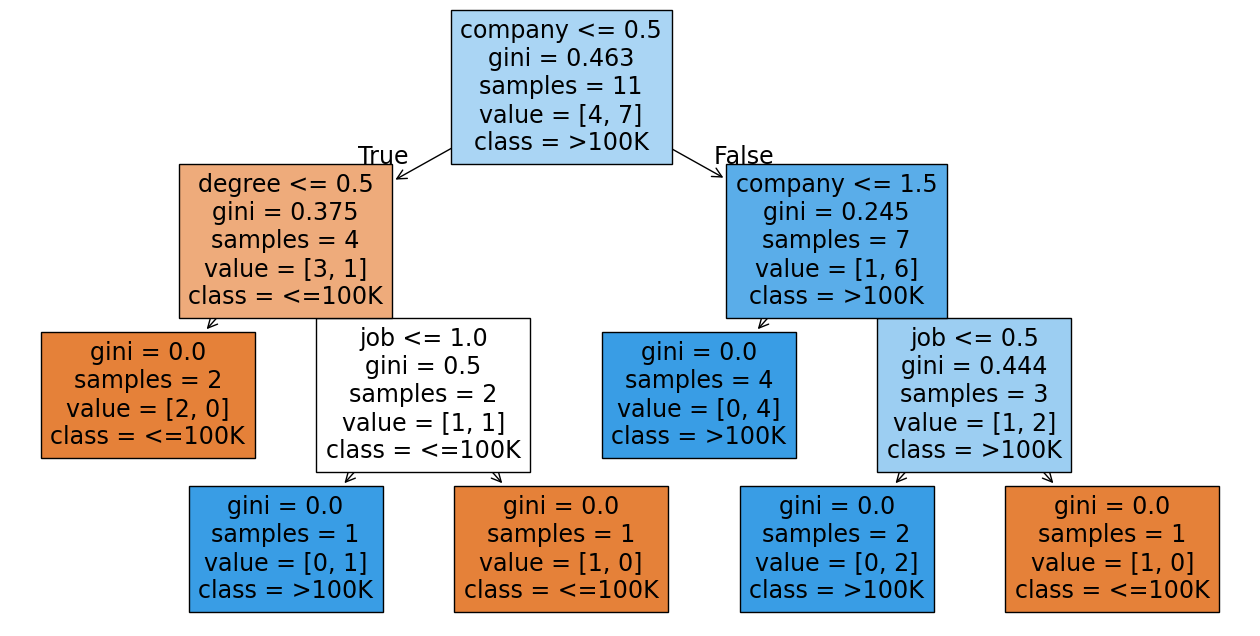

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))
plot_tree(cart_model, feature_names=X.columns, class_names=['<=100K', '>100K'], filled=True)
plt.show()


In [ ]:
id3_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

id3_model.fit(X_train, y_train)

y_pred_id3 = id3_model.predict(X_test)

print("ID3 Accuracy:", accuracy_score(y_test, y_pred_id3))
print(classification_report(y_test, y_pred_id3))


ID3 Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.67      0.80         3

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



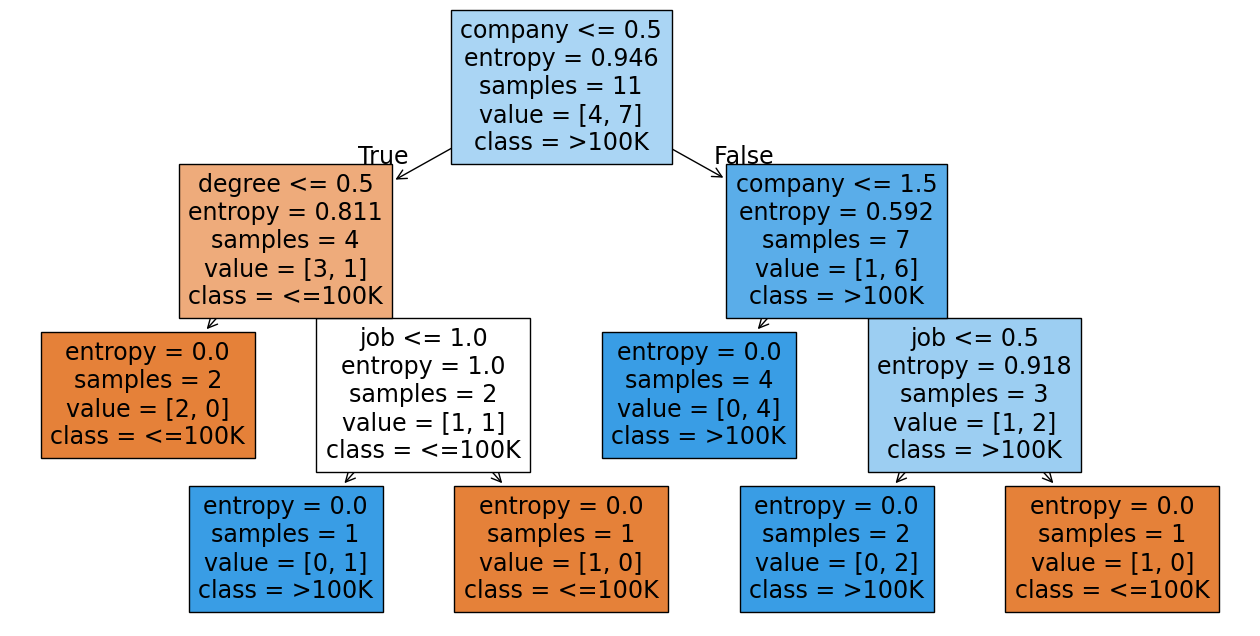

In [ ]:
plt.figure(figsize=(16,8))
plot_tree(id3_model, feature_names=X.columns, class_names=['<=100K', '>100K'], filled=True)
plt.show()


In [ ]:
print("CART Accuracy :", accuracy_score(y_test, y_pred_cart))
print("ID3 Accuracy  :", accuracy_score(y_test, y_pred_id3))


CART Accuracy : 0.8
ID3 Accuracy  : 0.8
